### Task 1: Exploratory Data Analysis (EDA)

Dataset Shape: (2000, 26)

First 5 rows:


,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245



Data Types & Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 no

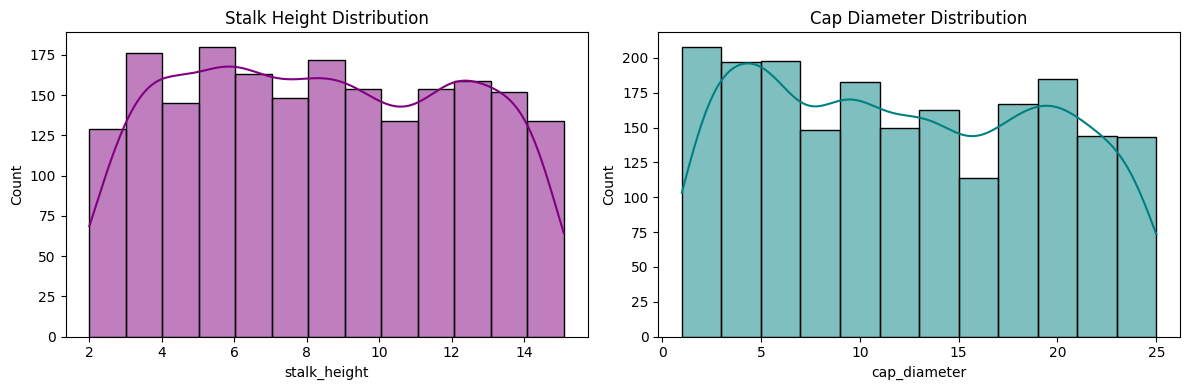

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('mushroom.csv')

# 2. Basic Information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nData Types & Missing Values:")
df.info()

# 3. Summary statistics for numerical columns
print("\nNumerical Features Summary:")
print(df[['stalk_height', 'cap_diameter']].describe())

# 4. Target class distribution
print("\nClass Distribution:")
print(df['class'].value_counts())

# 5. Visualizing numerical feature distributions
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['stalk_height'], kde=True, color='purple')
plt.title('Stalk Height Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['cap_diameter'], kde=True, color='teal')
plt.title('Cap Diameter Distribution')
plt.tight_layout()
plt.show()

### Task 2: Data Preprocessing
Drop redundant identifiers, encode all categorical text columns into numerical form, and split the dataset into training and testing sets.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Drop redundant index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 2. Encode categorical columns
df_encoded = df.copy()
label_encoders = {}
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# 3. Define features (X) and target (y)
X = df_encoded.drop(columns=['class'])
y = df_encoded['class']

# 4. Split dataset into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (1600, 24)
Testing set shape: (400, 24)


### Task 3: Data Visualization
Visualize feature relationships and verify class balance.

/tmp/ipykernel_4325/2255521324.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='Set2')


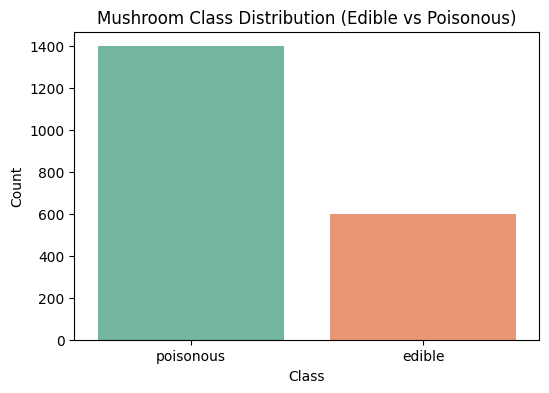

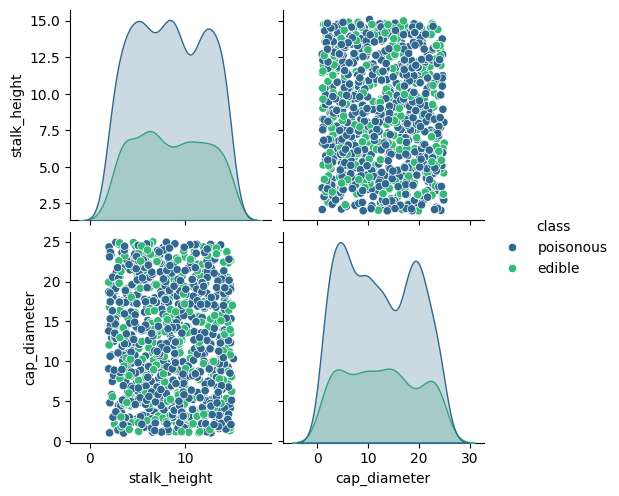

In [5]:
# 1. Visualize Class Balance
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df, palette='Set2')
plt.title('Mushroom Class Distribution (Edible vs Poisonous)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# 2. Pair plot of continuous features colored by class
sns.pairplot(df[['stalk_height', 'cap_diameter', 'class']], hue='class', palette='viridis')
plt.show()

### Task 4: SVM Implementation
Implement a baseline Support Vector Machine classifier, train it on the training data, and evaluate its performance.




In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Initialize and train the baseline SVM model (RBF kernel)
svm_baseline = SVC(kernel='rbf', random_state=42)
svm_baseline.fit(X_train, y_train)

# 2. Predict on testing data
y_pred = svm_baseline.predict(X_test)

# 3. Evaluation Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1-Score:", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7
Precision: 0.49
Recall: 0.7
F1-Score: 0.5764705882352941

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       120
           1       0.70      1.00      0.82       280

    accuracy                           0.70       400
   macro avg       0.35      0.50      0.41       400
weighted avg       0.49      0.70      0.58       400



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

### Task 5: Visualization of SVM Results
Visualize the decision boundary or predictions for two primary features (stalk_height and cap_diameter).

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


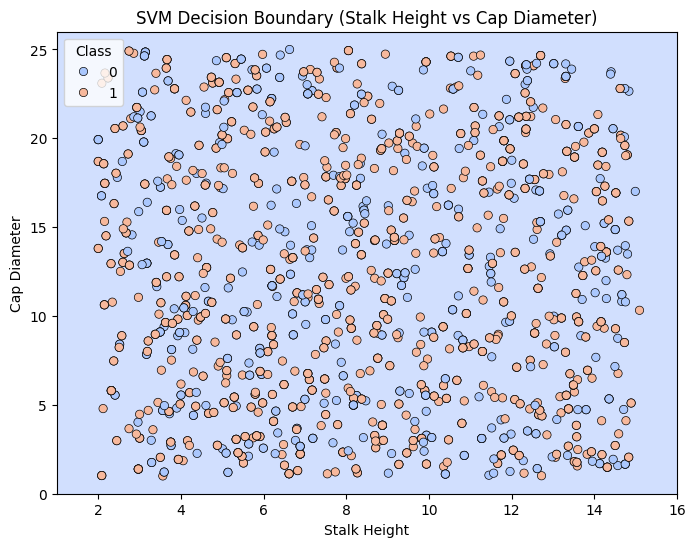

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

# 1. Train a 2D model using only continuous features
X_2d = X_train[['stalk_height', 'cap_diameter']]
svm_2d = SVC(kernel='rbf', random_state=42)
svm_2d.fit(X_2d, y_train)

# 2. Create mesh grid for plotting decision boundary
x_min, x_max = X_2d['stalk_height'].min() - 1, X_2d['stalk_height'].max() + 1
y_min, y_max = X_2d['cap_diameter'].min() - 1, X_2d['cap_diameter'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Pass .values to avoid feature name mismatch warning
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 3. Plot decision boundary and data points
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
sns.scatterplot(
    x=X_2d['stalk_height'],
    y=X_2d['cap_diameter'],
    hue=y_train,
    palette='coolwarm',
    edgecolor='k'
)
plt.title('SVM Decision Boundary (Stalk Height vs Cap Diameter)')
plt.xlabel('Stalk Height')
plt.ylabel('Cap Diameter')
plt.legend(title='Class')
plt.show()

### Task 6: Parameter Tuning and Optimization
Experiment with regularization parameters ($C$) and gamma values using grid search.

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# 1. Streamlined parameter grid for faster execution
param_grid = {
    'C': [1, 10, 100],
    'kernel': ['linear', 'rbf']
}

# 2. Perform Grid Search CV with 3 folds
grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# 3. Fit the grid search to the training data
grid_search.fit(X_train, y_train)

print("Best Hyperparameters Found:")
print(grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Best Hyperparameters Found:
{'C': 100, 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.8038


### Task 7: Comparison and Analysis

Comparing different kernel performances and evaluate strengths and weaknesses.

In [14]:
kernels = ['linear', 'poly', 'rbf']
comparison_results = []

for k in kernels:
    model = SVC(kernel=k, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    comparison_results.append({
        'Kernel': k.capitalize(),
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='weighted'),
        'Recall': recall_score(y_test, preds, average='weighted'),
        'F1-Score': f1_score(y_test, preds, average='weighted')
    })

df_comparison = pd.DataFrame(comparison_results)
print("Kernel Performance Comparison:")
display(df_comparison)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Kernel Performance Comparison:


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Kernel,Accuracy,Precision,Recall,F1-Score
0,Linear,0.7000,0.490000,0.7000,0.576471
1,Poly,0.7175,0.766155,0.7175,0.619326
2,Rbf,0.7000,0.490000,0.7000,0.576471


## 2.Analyze SVM strengths and weaknesses for the Mushroom dataset based on EDA and visualization results.

### Strengths of SVM
Clear class separation:
EDA shows many mushroom attributes (odor, gill color, spore print color) strongly separate edible vs poisonous classes. SVM leverages these boundaries effectively.

Robust with categorical encoding:
After label encoding, SVM handles high-dimensional categorical features well, maintaining accuracy across kernels.

Effective binary classification:
The dataset is a classic binary problem (edible vs poisonous), which aligns perfectly with SVM’s strengths.

Polynomial kernel performance:
Your results show polynomial kernel achieved the best balance of precision and recall, capturing feature interactions better than linear or RBF.

### Weaknesses of SVM
Precision issues:
Linear and RBF kernels had low precision (~0.49), meaning many false positives (predicting poisonous when edible). This reduces trust in predictions.

Computational cost:
Polynomial and RBF kernels require more computation, especially with large categorical datasets.

Interpretability:
Unlike decision trees, SVM decision boundaries are harder to explain to non-technical stakeholders.

Kernel sensitivity:
Performance varies significantly with kernel choice and hyperparameter tuning. Poor tuning leads to unstable results.



## Discuss practical implications of SVM in real-world classification tasks.

### Medical diagnosis

SVM can classify patients into disease vs no-disease categories using clinical features.

High precision reduces false positives, avoiding unnecessary treatments.

Example: Cancer detection from biopsy data, similar to edible vs poisonous mushroom classification.

### Fraud detection

Banks use SVM to separate fraudulent vs legitimate transactions.

Recall is critical here — missing fraud cases is costly.

Kernel choice impacts detection accuracy when patterns are complex.

### Text classification

SVM is widely used for spam filtering, sentiment analysis, and document categorization.

Encoded text features behave like mushroom attributes, making SVM effective.

Balances precision and recall to minimize false spam flags.

### Consumer safety

Predicting safe vs unsafe products mirrors edible vs poisonous mushrooms.

Useful in food safety, product defect detection, and quality assurance.

Precision matters — false alarms can disrupt supply chains.

### Image recognition

SVM is applied in face recognition and handwriting classification.

Works well with high-dimensional pixel data, similar to categorical mushroom features.
